<a href="https://colab.research.google.com/github/Diego-Cano-bit/CIMAT-Monterrey/blob/main/Log_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import logit
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
plt.ioff() # Interactive Mode Off
plt.style.use('seaborn')

<ipython-input-2-15ed9f9ce44b>:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [ ]:
print(sm.datasets.fair.SOURCE)


Fair, Ray. 1978. "A Theory of Extramarital Affairs," `Journal of Political
Economy`, February, 45-61.

The data is available at http://fairmodel.econ.yale.edu/rayfair/pdf/2011b.htm



In [ ]:
print( sm.datasets.fair.NOTE)


::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [ ]:
dta = sm.datasets.fair.load_pandas().data
dta

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666
...,...,...,...,...,...,...,...,...,...
6361,5.0,32.0,13.0,2.0,3.0,17.0,4.0,3.0,0.000000
6362,4.0,32.0,13.0,1.0,1.0,16.0,5.0,5.0,0.000000
6363,5.0,22.0,2.5,0.0,2.0,14.0,3.0,1.0,0.000000
6364,5.0,32.0,6.0,1.0,3.0,14.0,3.0,4.0,0.000000


In [ ]:
print(dta.describe())

       rate_marriage          age  yrs_married     children    religious  \
count    6366.000000  6366.000000  6366.000000  6366.000000  6366.000000   
mean        4.109645    29.082862     9.009425     1.396874     2.426170   
std         0.961430     6.847882     7.280120     1.433471     0.878369   
min         1.000000    17.500000     0.500000     0.000000     1.000000   
25%         4.000000    22.000000     2.500000     0.000000     2.000000   
50%         4.000000    27.000000     6.000000     1.000000     2.000000   
75%         5.000000    32.000000    16.500000     2.000000     3.000000   
max         5.000000    42.000000    23.000000     5.500000     4.000000   

              educ   occupation  occupation_husb      affairs  
count  6366.000000  6366.000000      6366.000000  6366.000000  
mean     14.209865     3.424128         3.850141     0.705374  
std       2.178003     0.942399         1.346435     2.203374  
min       9.000000     1.000000         1.000000     0.0000

In [ ]:
dta['affair'] = (dta['affairs'] > 0).astype(int)
dta['affair']

0       1
1       1
2       1
3       1
4       1
       ..
6361    0
6362    0
6363    0
6364    0
6365    0
Name: affair, Length: 6366, dtype: int64

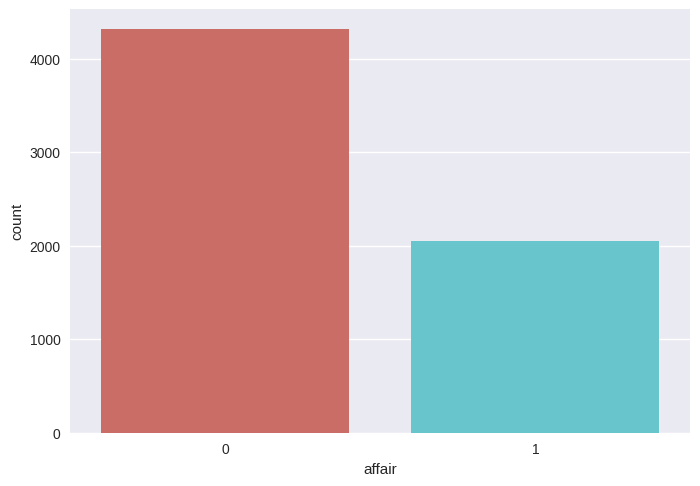

In [ ]:
sns.countplot(x='affair',data=dta, palette='hls')
plt.show()

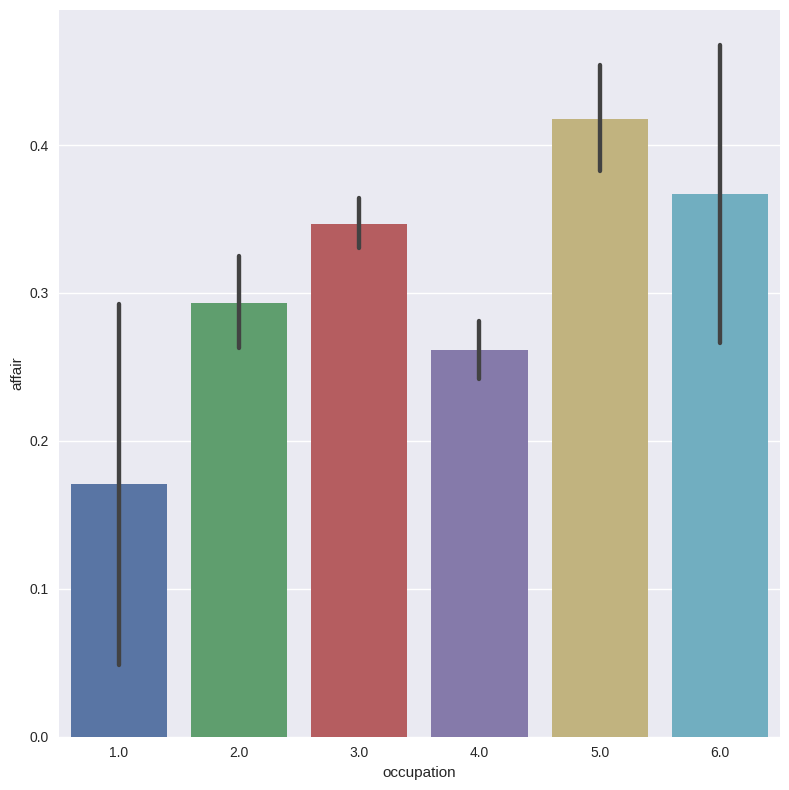

In [ ]:
sns.catplot(x="occupation", y="affair", data=dta, kind="bar", height = 8)
plt.show()


In [ ]:
data = dta
cat_vars = ['rate_marriage', 'religious','educ', 'occupation','occupation_husb']
# Una forma de hacerlo es mediante Pandas...
cat_dummy = pd.get_dummies(data['rate_marriage'], prefix='rate_marriage',drop_first=True)
cat_dummy

,rate_marriage_2.0,rate_marriage_3.0,rate_marriage_4.0,rate_marriage_5.0
0,0,1,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,1,0
4,0,0,0,1
...,...,...,...,...
6361,0,0,0,1
6362,0,0,1,0
6363,0,0,0,1
6364,0,0,0,1


In [ ]:
from patsy import dmatrices
data = dta
cat_vars = ['rate_marriage', 'religious','educ', 'occupation','occupation_husb']

y, X = dmatrices('affair ~ C(occupation) + C(educ) + C(occupation_husb)'
    '+ C(rate_marriage) + age + yrs_married + children'
    '+ C(religious)', data, return_type = 'dataframe')


In [ ]:
X

,Intercept,C(occupation)[T.2.0],C(occupation)[T.3.0],C(occupation)[T.4.0],C(occupation)[T.5.0],C(occupation)[T.6.0],C(educ)[T.12.0],C(educ)[T.14.0],C(educ)[T.16.0],C(educ)[T.17.0],...,C(rate_marriage)[T.2.0],C(rate_marriage)[T.3.0],C(rate_marriage)[T.4.0],C(rate_marriage)[T.5.0],C(religious)[T.2.0],C(religious)[T.3.0],C(religious)[T.4.0],age,yrs_married,children
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,32.0,9.0,3.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,27.0,13.0,3.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,22.0,2.5,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,37.0,16.5,4.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,27.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6361,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,32.0,13.0,2.0
6362,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,32.0,13.0,1.0
6363,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,22.0,2.5,0.0
6364,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,32.0,6.0,1.0


import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_2893051316242672510, *['C(occupation)[T.2.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_2893051316242672510, *['C(occupation)[T.3.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_2893051316242672510, *['C(occupation)[T.4.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_2893051316242672510, *['C(occupation)[T.5.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_2893051316242672510, *['C(occupation)[T.2.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_2893051316242672510, *['C(occupation)[T.3.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_2893051316242672510, *['C(occupation)[T.4.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_2893051316242672510, *['C(occupation)[T.5.0]'], **{})
chart

import numpy as np
from google.colab import autoviz
df_2893051316242672510 = autoviz.get_df('df_2893051316242672510')

def scatter_plots(df, colname_pairs, scatter_plot_size=2.5, size=8, alpha=.6):
  from matplotlib import pyplot as plt
  plt.figure(figsize=(len(colname_pairs) * scatter_plot_size, scatter_plot_size))
  for plot_i, (x_colname, y_colname) in enumerate(colname_pairs, start=1):
    ax = plt.subplot(1, len(colname_pairs), plot_i)
    ax.scatter(df[x_colname], df[y_colname], s=size, alpha=alpha)
    plt.xlabel(x_colname)
    plt.ylabel(y_colname)
    ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = scatter_plots(df_2893051316242672510, *[[['C(occupation)[T.2.0]', 'C(occupation)[T.3.0]'], ['C(occupation)[T.3.0]', 'C(occupation)[T.4.0]'], ['C(occupation)[T.4.0]', 'C(occupation)[T.5.0]'], ['C(occupation)[T.5.0]', 'C(occupation)[T.6.0]']]], **{})
chart

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, pd.Series.ravel(y),test_size=0.3, random_state=0)


In [ ]:
logit_model=sm.Logit(y_train,X_train)
result=logit_model.fit(method='newton')
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.540886
         Iterations 6
                             Results: Logit
Model:                 Logit              Pseudo R-squared:   0.142      
Dependent Variable:    y                  AIC:                4872.3800  
Date:                  2023-07-18 16:46   BIC:                5038.8322  
No. Observations:      4456               Log-Likelihood:     -2410.2    
Df Model:              25                 LL-Null:            -2808.3    
Df Residuals:          4430               LLR p-value:        7.8883e-152
Converged:             1.0000             Scale:              1.0000     
No. Iterations:        6.0000                                            
-------------------------------------------------------------------------
                           Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------------------
Intercept                  0.2497   0.85

In [ ]:
y_pred1 = result.predict(X_test)
y_pred1 = [0 if x < 0.5 else 1 for x in y_pred1]
confusion_matrix = metrics.confusion_matrix(y_test, y_pred1)
print(confusion_matrix)


[[1156  147]
 [ 369  238]]


In [ ]:
print(metrics.classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

         0.0       0.76      0.89      0.82      1303
         1.0       0.62      0.39      0.48       607

    accuracy                           0.73      1910
   macro avg       0.69      0.64      0.65      1910
weighted avg       0.71      0.73      0.71      1910



In [ ]:
logreg = LogisticRegression(solver='newton-cg', C = 1e9)
logreg.fit(X_train, y_train)

LogisticRegression(C=1000000000.0, solver='newton-cg')

In [ ]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.73


In [ ]:
y_pred2 = logreg.predict(X_test)
confusion_matrix = metrics.confusion_matrix(y_test, y_pred2)
print(confusion_matrix)

[[1156  147]
 [ 369  238]]


In [ ]:
print(metrics.classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

         0.0       0.76      0.89      0.82      1303
         1.0       0.62      0.39      0.48       607

    accuracy                           0.73      1910
   macro avg       0.69      0.64      0.65      1910
weighted avg       0.71      0.73      0.71      1910



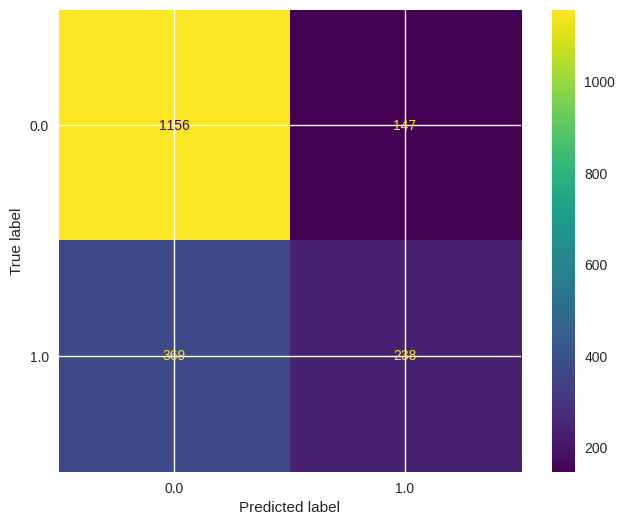

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
plt.rcParams['figure.figsize'] = (8, 6)
dif = ConfusionMatrixDisplay.from_predictions(y_test, y_pred),{'fontsize':15}
#disp1.ax_.set_title('Matriz de confusion. Sin normalizar',{'fontsize':15})
#plt.plot(dif)
plt.show()

In [ ]:
np.round(logreg.coef_,4)

array([[ 0.1249,  1.0383,  1.2665,  1.0714,  1.6463,  2.0136,  0.3753,
         0.6273,  0.3319,  0.5494,  0.2733,  0.0863,  0.2019,  0.0396,
         0.0062, -0.0144, -0.2886, -0.6063, -1.4842, -2.2724, -0.4057,
        -0.7049, -1.3248, -0.0583,  0.1105, -0.0146]])

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

centers = [[-1, 0], [0, 8], [3, -1]]
X, y = make_blobs(n_samples=5000, centers=centers, random_state=100)
transformation = [[0.4, 0.2], [-0.4, 1.2]]
X = np.dot(X, transformation)

for multi_class in ('multinomial', 'ovr'):
    clf = LogisticRegression(solver='sag', max_iter=200, random_state=42,multi_class=multi_class).fit(X, y)
    # print the training scores
    print("training score : %.3f (%s)" % (clf.score(X, y), multi_class))
    # create a mesh to plot in
    h = .02 # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h))
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)
    plt.title("Decision surface of LogisticRegression (%s)" % multi_class)
    plt.axis('tight')
    # Plot also the training points
    colors = "bry"
for i, color in zip(clf.classes_, colors):
  idx = np.where(y == i)
  plt.scatter(X[idx, 0], X[idx, 1], c=color, cmap=plt.cm.Paired,edgecolor='black', s=20)
# Plot the three one-against-all classifiers
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
coef = clf.coef_
intercept = clf.intercept_
def plot_hyperplane(c, color):
  def line(x0):
    return (-(x0 * coef[c, 0]) - intercept[c]) / coef[c, 1]
    plt.plot([xmin, xmax], [line(xmin), line(xmax)],ls="--", color=color)
for i, color in zip(clf.classes_, colors):
  plot_hyperplane(i, color)



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


training score : 0.984 (multinomial)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


training score : 0.983 (ovr)


<ipython-input-60-63c6db34572f>:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, cmap=plt.cm.Paired,edgecolor='black', s=20)


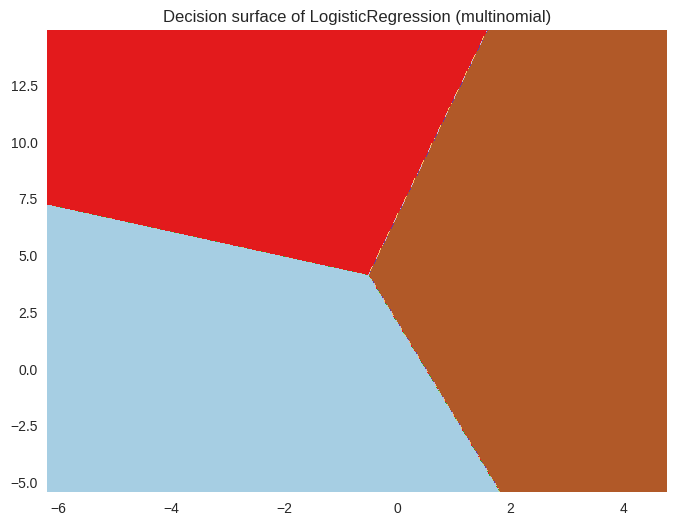

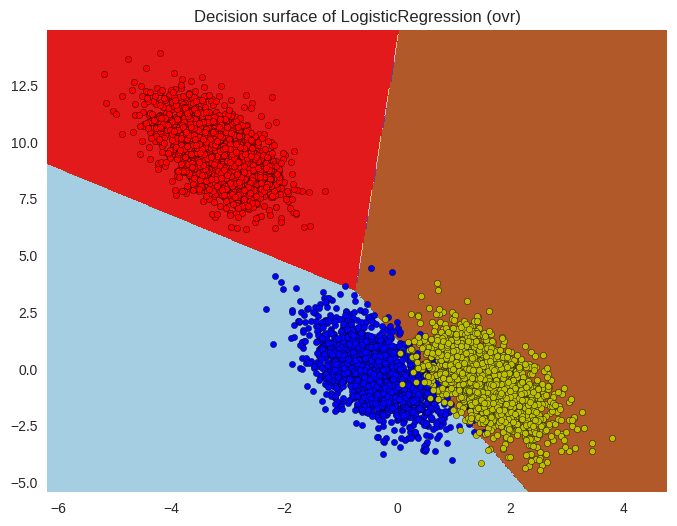

In [ ]:
plt.show()
